# import the required libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the dataset

In [58]:
df = pd.read_csv("smartcare_ai_dataset_1000.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,...,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,...,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,...,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,...,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,...,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,...,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


# Basic dataset information

In [59]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows: 1000
Number of columns: 33

Column names:
['record_id', 'patient_id', 'age', 'gender', 'blood_group', 'department', 'diagnosis', 'appointment_date', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'appointment_status', 'admitted', 'room_type', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'payment_status', 'payment_method', 'no_show', 'readmitted_30_days', 'disease_risk_level']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   o

# Check missing values

In [60]:
missing = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values(
    "Missing Values",
    ascending=False
)

print(missing_table)

           Missing Values  Percentage
room_type             906        90.6


# Visualize missing values

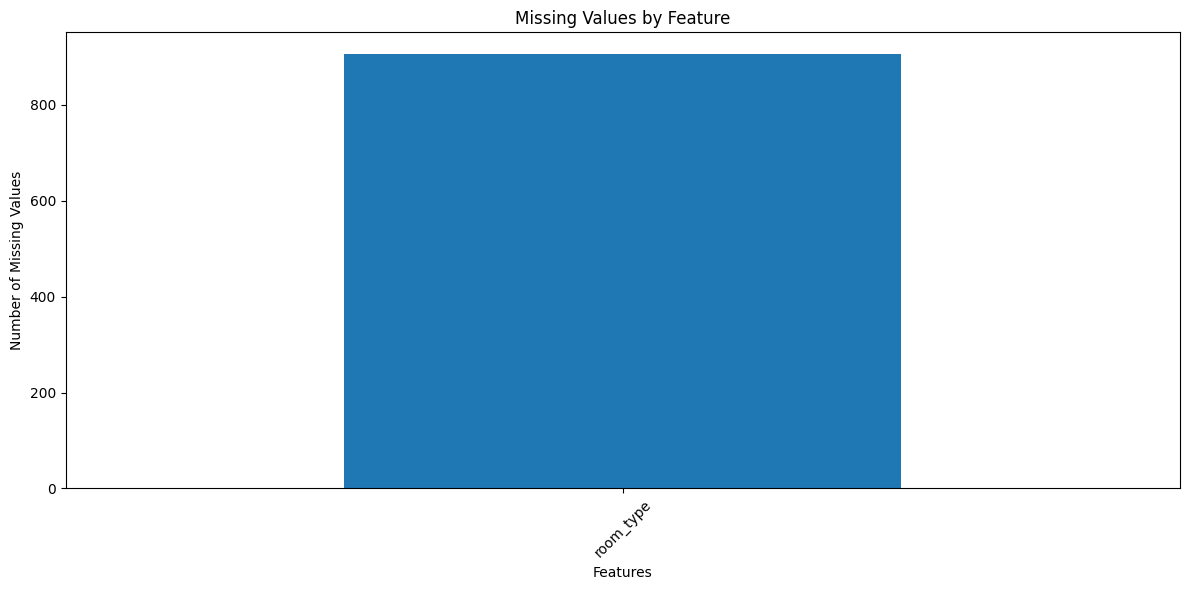

In [61]:
plt.figure(figsize=(12, 6))

missing_plot = df.isnull().sum()
missing_plot = missing_plot[missing_plot > 0]

missing_plot.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Handle room_type

In [62]:
print("Missing room_type before:")
print(df["room_type"].isnull().sum())

df["room_type"] = df["room_type"].fillna("None")

print("\nMissing room_type after:")
print(df["room_type"].isnull().sum())

Missing room_type before:
906

Missing room_type after:
0


# Check all remaining missing values

In [64]:
print("Total missing values after cleaning:",
      df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

Total missing values after cleaning: 0

Missing values by column:
record_id                       0
patient_id                      0
age                             0
gender                          0
blood_group                     0
department                      0
diagnosis                       0
appointment_date                0
waiting_days                    0
previous_appointments           0
missed_previous_appointments    0
appointment_status              0
admitted                        0
room_type                       0
length_of_stay_days             0
previous_admissions             0
systolic_bp                     0
diastolic_bp                    0
blood_sugar_mg_dl               0
cholesterol_mg_dl               0
bmi                             0
lab_tests_count                 0
treatments_count                0
consultation_fee_lkr            0
room_charge_lkr                 0
lab_charge_lkr                  0
medicine_charge_lkr             0
total_bill_lkr  

# Detect duplicate records

In [65]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [66]:
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (1000, 33)


# Check duplicate IDs

In [67]:
print("Duplicate record_id:",
      df["record_id"].duplicated().sum())

print("Duplicate patient_id:",
      df["patient_id"].duplicated().sum())

Duplicate record_id: 0
Duplicate patient_id: 0


# Check data types

In [68]:
print(df.dtypes)

record_id                         int64
patient_id                       object
age                               int64
gender                           object
blood_group                      object
department                       object
diagnosis                        object
appointment_date                 object
waiting_days                      int64
previous_appointments             int64
missed_previous_appointments      int64
appointment_status               object
admitted                          int64
room_type                        object
length_of_stay_days               int64
previous_admissions               int64
systolic_bp                       int64
diastolic_bp                      int64
blood_sugar_mg_dl                 int64
cholesterol_mg_dl                 int64
bmi                             float64
lab_tests_count                   int64
treatments_count                  int64
consultation_fee_lkr              int64
room_charge_lkr                   int64


# Convert appointment date

In [69]:
df["appointment_date"] = pd.to_datetime(
    df["appointment_date"],
    errors="coerce"
)

print(df["appointment_date"].dtype)

datetime64[ns]


In [70]:
print(
    "Invalid appointment dates:",
    df["appointment_date"].isnull().sum()
)

Invalid appointment dates: 0


# Create feature: appointment month

In [71]:
df["appointment_month"] = (
    df["appointment_date"].dt.month
)

print(
    df[["appointment_date", "appointment_month"]].head()
)

  appointment_date  appointment_month
0       2025-04-10                  4
1       2025-05-15                  5
2       2025-07-09                  7
3       2025-10-16                 10
4       2025-12-18                 12


# Create feature: appointment day

In [72]:
df["appointment_dayofweek"] = (
    df["appointment_date"].dt.dayofweek
)

print(
    df[[
        "appointment_date",
        "appointment_dayofweek"
    ]].head()
)

  appointment_date  appointment_dayofweek
0       2025-04-10                      3
1       2025-05-15                      3
2       2025-07-09                      2
3       2025-10-16                      3
4       2025-12-18                      3


# Create feature: previous missed rate

In [73]:
df["previous_missed_rate"] = np.where(
    df["previous_appointments"] > 0,
    df["missed_previous_appointments"] /
    df["previous_appointments"],
    0
)

print(
    df[[
        "previous_appointments",
        "missed_previous_appointments",
        "previous_missed_rate"
    ]].head(10)
)

   previous_appointments  missed_previous_appointments  previous_missed_rate
0                      1                             0              0.000000
1                      3                             1              0.333333
2                      7                             1              0.142857
3                      1                             0              0.000000
4                      4                             0              0.000000
5                      1                             0              0.000000
6                      4                             0              0.000000
7                      3                             0              0.000000
8                      4                             1              0.250000
9                      4                             1              0.250000


# Create feature: previous appointment indicator

In [74]:
df["has_previous_appointment"] = (
    df["previous_appointments"] > 0
).astype(int)

print(
    df[[
        "previous_appointments",
        "has_previous_appointment"
    ]].head(10)
)

   previous_appointments  has_previous_appointment
0                      1                         1
1                      3                         1
2                      7                         1
3                      1                         1
4                      4                         1
5                      1                         1
6                      4                         1
7                      3                         1
8                      4                         1
9                      4                         1


# Create blood-pressure category

In [75]:
def categorize_blood_pressure(row):

    systolic = row["systolic_bp"]
    diastolic = row["diastolic_bp"]

    if systolic < 120 and diastolic < 80:
        return "Normal"

    elif systolic < 130 and diastolic < 80:
        return "Elevated"

    elif systolic < 140 or diastolic < 90:
        return "High"

    else:
        return "Very High"


df["bp_category"] = df.apply(
    categorize_blood_pressure,
    axis=1
)

print(df["bp_category"].value_counts())

bp_category
High         683
Normal       168
Elevated     122
Very High     27
Name: count, dtype: int64


# Check the engineered features

In [76]:
engineered_features = [
    "appointment_month",
    "appointment_dayofweek",
    "previous_missed_rate",
    "has_previous_appointment",
    "bp_category"
]

df[engineered_features].head(10)

,appointment_month,appointment_dayofweek,previous_missed_rate,has_previous_appointment,bp_category
0,4,3,0.000000,1,Elevated
1,5,3,0.333333,1,High
2,7,2,0.142857,1,High
3,10,3,0.000000,1,High
4,12,3,0.000000,1,High
5,10,0,0.000000,1,Normal
6,4,2,0.000000,1,High
7,7,6,0.000000,1,High
8,6,0,0.250000,1,Normal
9,6,2,0.250000,1,Elevated


# Detect numerical outliers

In [77]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['record_id', 'age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'admitted', 'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count', 'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr', 'medicine_charge_lkr', 'total_bill_lkr', 'no_show', 'readmitted_30_days', 'previous_missed_rate', 'has_previous_appointment']


# Create boxplots

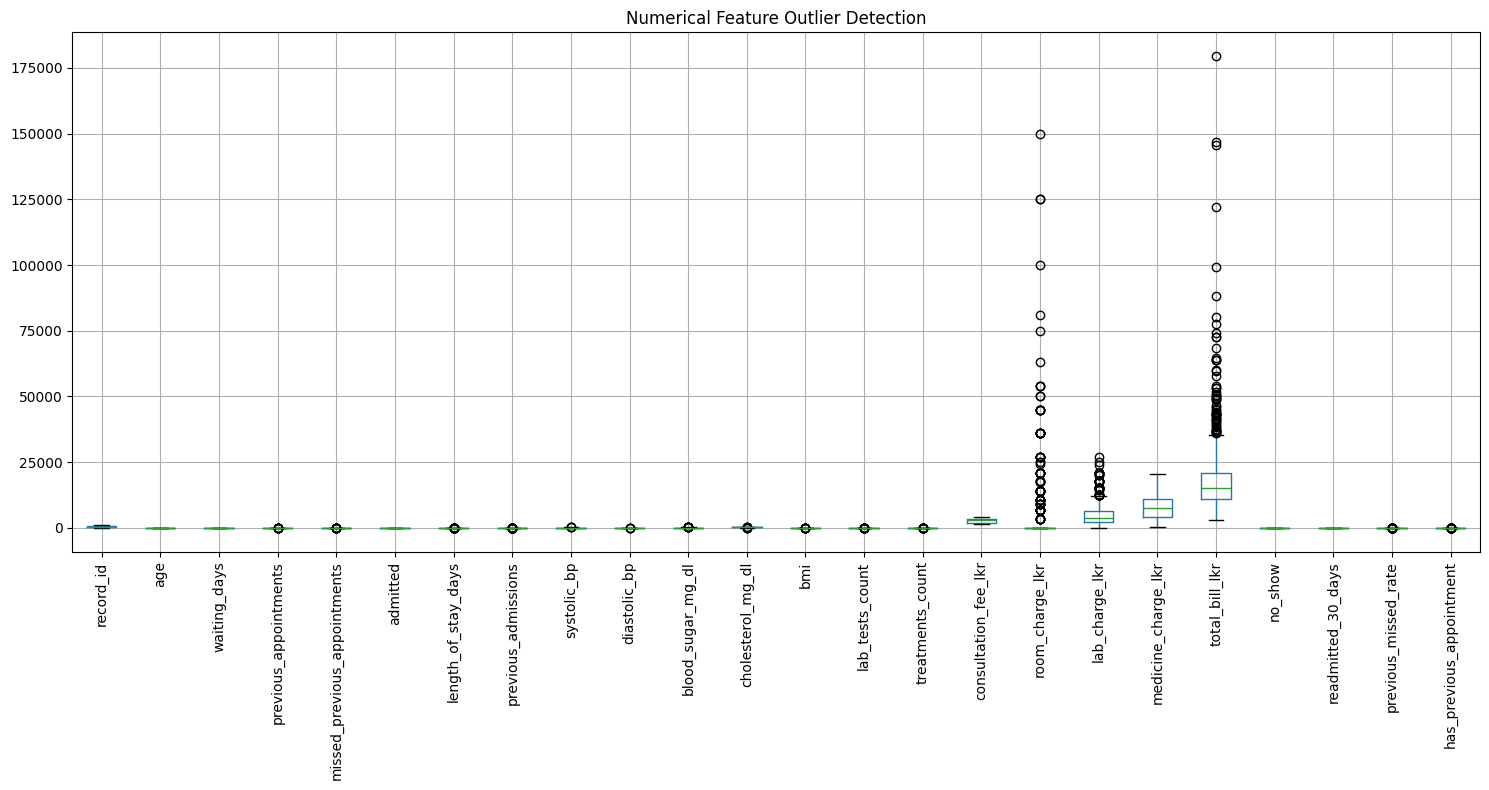

In [78]:
plt.figure(figsize=(15, 8))

df[numerical_columns].boxplot()

plt.title("Numerical Feature Outlier Detection")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Calculate IQR outliers

In [79]:
outlier_results = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_results.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_table = pd.DataFrame(outlier_results)

outlier_table.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
16,room_charge_lkr,0.00,0.000000,0.000000,0.00,0.000000,94
17,lab_charge_lkr,2400.00,6300.000000,3900.000000,-3450.00,12150.000000,61
7,previous_admissions,0.00,1.000000,1.000000,-1.50,2.500000,60
19,total_bill_lkr,11018.00,20870.000000,9852.000000,-3760.00,35648.000000,59
22,previous_missed_rate,0.00,0.333333,0.333333,-0.50,0.833333,51
6,length_of_stay_days,0.00,2.000000,2.000000,-3.00,5.000000,48
23,has_previous_appointment,1.00,1.000000,0.000000,1.00,1.000000,45
13,lab_tests_count,1.00,3.000000,2.000000,-2.00,6.000000,23
14,treatments_count,1.00,3.000000,2.000000,-2.00,6.000000,17
4,missed_previous_appointments,0.00,1.000000,1.000000,-1.50,2.500000,17


# Select target

In [80]:
target = "no_show"

print("Target:", target)

print("\nTarget distribution:")
print(df[target].value_counts())

print("\nTarget percentage:")
print(
    df[target].value_counts(normalize=True) * 100
)

Target: no_show

Target distribution:
no_show
0    505
1    495
Name: count, dtype: int64

Target percentage:
no_show
0    50.5
1    49.5
Name: proportion, dtype: float64


# Check target visualization

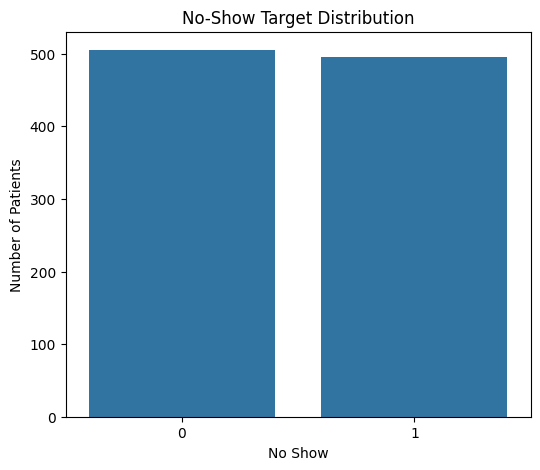

In [81]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="no_show"
)

plt.title("No-Show Target Distribution")
plt.xlabel("No Show")
plt.ylabel("Number of Patients")

plt.show()

# Select useful features

In [82]:
features = [
    "age",
    "gender",
    "blood_group",
    "department",
    "diagnosis",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_missed_rate",
    "has_previous_appointment",
    "appointment_month",
    "appointment_dayofweek",
    "bp_category",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi"
]

X = df[features]
y = df[target]

print("Number of selected features:", len(features))
print("\nSelected features:")
print(features)

Number of selected features: 18

Selected features:
['age', 'gender', 'blood_group', 'department', 'diagnosis', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_missed_rate', 'has_previous_appointment', 'appointment_month', 'appointment_dayofweek', 'bp_category', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']


# Check categorical and numerical features

In [83]:
categorical_features = [
    "gender",
    "blood_group",
    "department",
    "diagnosis",
    "bp_category"
]

numerical_features = [
    "age",
    "waiting_days",
    "previous_appointments",
    "missed_previous_appointments",
    "previous_missed_rate",
    "has_previous_appointment",
    "appointment_month",
    "appointment_dayofweek",
    "systolic_bp",
    "diastolic_bp",
    "blood_sugar_mg_dl",
    "cholesterol_mg_dl",
    "bmi"
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'blood_group', 'department', 'diagnosis', 'bp_category']

Numerical features:
['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments', 'previous_missed_rate', 'has_previous_appointment', 'appointment_month', 'appointment_dayofweek', 'systolic_bp', 'diastolic_bp', 'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi']


# Split training and testing data

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training records: 800
Testing records: 200

Training target distribution:
no_show
0    404
1    396
Name: count, dtype: int64

Testing target distribution:
no_show
0    101
1     99
Name: count, dtype: int64


# Build preprocessing pipeline

In [85]:
preprocessor = ColumnTransformer(
    transformers=[

        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


# Fit preprocessing

In [86]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (800, 18)
Processed training shape: (800, 44)
Original testing shape: (200, 18)
Processed testing shape: (200, 44)


# Get final feature names

In [87]:
feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    "Total final ML features:",
    len(feature_names)
)

print("\nFinal features:")

for feature in feature_names:
    print(feature)

Total final ML features: 44

Final features:
numerical__age
numerical__waiting_days
numerical__previous_appointments
numerical__missed_previous_appointments
numerical__previous_missed_rate
numerical__has_previous_appointment
numerical__appointment_month
numerical__appointment_dayofweek
numerical__systolic_bp
numerical__diastolic_bp
numerical__blood_sugar_mg_dl
numerical__cholesterol_mg_dl
numerical__bmi
categorical__gender_Female
categorical__gender_Male
categorical__blood_group_A+
categorical__blood_group_A-
categorical__blood_group_AB+
categorical__blood_group_AB-
categorical__blood_group_B+
categorical__blood_group_B-
categorical__blood_group_O+
categorical__blood_group_O-
categorical__department_Cardiology
categorical__department_General Medicine
categorical__department_Laboratory Services
categorical__department_Neurology
categorical__department_Orthopedics
categorical__department_Pediatrics
categorical__department_Radiology
categorical__diagnosis_Asthma
categorical__diagnosis_Bac

# Create final processed training dataset

In [88]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

print("Processed training dataset:")
display(X_train_processed_df.head())

Processed training dataset:


,numerical__age,numerical__waiting_days,numerical__previous_appointments,numerical__missed_previous_appointments,numerical__previous_missed_rate,numerical__has_previous_appointment,numerical__appointment_month,numerical__appointment_dayofweek,numerical__systolic_bp,numerical__diastolic_bp,...,categorical__diagnosis_Fever,categorical__diagnosis_Fracture,categorical__diagnosis_Hypertension,categorical__diagnosis_Kidney Infection,categorical__diagnosis_Migraine,categorical__diagnosis_Pneumonia,categorical__bp_category_Elevated,categorical__bp_category_High,categorical__bp_category_Normal,categorical__bp_category_Very High
0,0.230917,-0.314725,1.805057,1.961203,0.554024,0.226381,-1.005995,0.499820,0.482437,-0.266617,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.379131,0.381869,0.061041,-0.748576,-0.664830,0.226381,-1.296850,1.513396,-0.420973,-0.959128,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.157296,1.078462,-1.101637,-0.748576,-0.664830,0.226381,-1.587705,0.499820,-0.937207,-0.365547,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.157296,-1.707912,-1.101637,-0.748576,-0.664830,0.226381,-0.133430,-1.527333,0.998672,0.623755,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.379131,0.072272,0.642379,1.961203,1.163451,0.226381,-1.587705,-0.006968,1.579435,2.008777,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Add target back

In [89]:
train_final = X_train_processed_df.copy()
train_final["no_show"] = y_train.reset_index(drop=True)

test_final = X_test_processed_df.copy()
test_final["no_show"] = y_test.reset_index(drop=True)

print("Final training dataset shape:")
print(train_final.shape)

print("\nFinal testing dataset shape:")
print(test_final.shape)

Final training dataset shape:
(800, 45)

Final testing dataset shape:
(200, 45)


# Check final dataset

In [90]:
print("Missing values:")
print(train_final.isnull().sum().sum())

print("\nDuplicate records:")
print(train_final.duplicated().sum())

print("\nFinal dataset preview:")
display(train_final.head())

Missing values:
0

Duplicate records:
0

Final dataset preview:


,numerical__age,numerical__waiting_days,numerical__previous_appointments,numerical__missed_previous_appointments,numerical__previous_missed_rate,numerical__has_previous_appointment,numerical__appointment_month,numerical__appointment_dayofweek,numerical__systolic_bp,numerical__diastolic_bp,...,categorical__diagnosis_Fracture,categorical__diagnosis_Hypertension,categorical__diagnosis_Kidney Infection,categorical__diagnosis_Migraine,categorical__diagnosis_Pneumonia,categorical__bp_category_Elevated,categorical__bp_category_High,categorical__bp_category_Normal,categorical__bp_category_Very High,no_show
0,0.230917,-0.314725,1.805057,1.961203,0.554024,0.226381,-1.005995,0.499820,0.482437,-0.266617,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,-0.379131,0.381869,0.061041,-0.748576,-0.664830,0.226381,-1.296850,1.513396,-0.420973,-0.959128,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
2,-0.157296,1.078462,-1.101637,-0.748576,-0.664830,0.226381,-1.587705,0.499820,-0.937207,-0.365547,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,-0.157296,-1.707912,-1.101637,-0.748576,-0.664830,0.226381,-0.133430,-1.527333,0.998672,0.623755,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,-0.379131,0.072272,0.642379,1.961203,1.163451,0.226381,-1.587705,-0.006968,1.579435,2.008777,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1


# Save the processed datasets

In [91]:
train_final.to_csv(
    "smartcare_preprocessed_train.csv",
    index=False
)

test_final.to_csv(
    "smartcare_preprocessed_test.csv",
    index=False
)

print("Datasets saved successfully!")

Datasets saved successfully!


# Save the complete cleaned dataset

In [92]:
df.to_csv(
    "smartcare_cleaned_feature_engineered.csv",
    index=False
)

print(
    "Cleaned + feature-engineered dataset saved!"
)

Cleaned + feature-engineered dataset saved!


# Save the preprocessing pipeline

In [93]:
import joblib

joblib.dump(
    preprocessor,
    "smartcare_preprocessor.joblib"
)

print("Preprocessing pipeline saved!")

Preprocessing pipeline saved!


# Final verification

In [94]:
print("=" * 60)
print("SMARTCARE PREPROCESSING COMPLETE")
print("=" * 60)

print("\nOriginal dataset:")
print(df.shape)

print("\nTraining dataset:")
print(train_final.shape)

print("\nTesting dataset:")
print(test_final.shape)

print("\nMissing values in training:")
print(train_final.isnull().sum().sum())

print("\nDuplicate rows in training:")
print(train_final.duplicated().sum())

print("\nSaved files:")
print("1. smartcare_cleaned_feature_engineered.csv")
print("2. smartcare_preprocessed_train.csv")
print("3. smartcare_preprocessed_test.csv")
print("4. smartcare_preprocessor.joblib")

SMARTCARE PREPROCESSING COMPLETE

Original dataset:
(1000, 38)

Training dataset:
(800, 45)

Testing dataset:
(200, 45)

Missing values in training:
0

Duplicate rows in training:
0

Saved files:
1. smartcare_cleaned_feature_engineered.csv
2. smartcare_preprocessed_train.csv
3. smartcare_preprocessed_test.csv
4. smartcare_preprocessor.joblib


In [96]:
from google.colab import files

files.download("smartcare_final_preprocessed_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>